# Resources Plots

In [1]:
import warnings

from pathlib import Path
import ipywidgets as widgets
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
import RES.RESources as RES_module

from RES import utility as utils
from RES.hdf5_handler import DataHandler

import RES.visual_styles as styles
style_path = Path(styles.__file__).parent / "elsevier.mplstyle"
plt.style.use(style_path)
# Suppress specific warnings
warnings.filterwarnings("ignore", category=UserWarning)
cfg=utils.load_config('config/config_CAN.yaml')

 └> CODERS API key loaded from: data/downloaded_data/CODERS/coders_api.yaml
  └> user Elias: w0OksqQKMFMtKPbO


----

## Select Region

In [2]:
# Construct region_options as a list of tuples: (name, code)
region_options = [(cfg['region_mapping'][code]['name'], code) for code in cfg['region_mapping']]
region_code = 'BC'  # Default selection, change as needed

# Create dropdown widget for region codes with names shown, codes as values
region_code_dropdown = widgets.Dropdown(
    options=region_options,
    value=region_code,
    description='Region:',
    disabled=False,
)

display(region_code_dropdown)

Dropdown(description='Region:', index=1, options=(('Alberta', 'AB'), ('British Columbia', 'BC'), ('Manitoba', …

## Select Resource type

In [3]:
resource_type_dropdown = widgets.Dropdown(
    options=['wind', 'solar'],
    value='wind',
    description='Resource:',)
display(resource_type_dropdown)


Dropdown(description='Resource:', options=('wind', 'solar'), value='wind')

In [4]:
resource_type = resource_type_dropdown.value
province_code = region_code_dropdown.value



required_args = {
    "config_file_path": 'config/config_CAN.yaml',
    "region_short_code": province_code,
    "resource_type": resource_type
}


# Create an instance of Resources and execute the module
RES_module = RES_module.RESources_builder(**required_args)

____________________________________________________________
     Initiating RESource Builder | RES.RESources
____________________________________________________________


  └─> RES.boundaries| Region Set to >> Short Code : BC, Name: British Columbia).
  └─> RES.boundaries| Collecting regional boundary...
  └─> RES.boundaries| Loading GADM boundaries (Sub-provincial | level =2) for British Columbia from local file data/processed_data/regions/gadm41_Canada_L2_BC.geojson.
  └─> RES.boundaries| Region Set to >> Short Code : BC, Name: British Columbia).
  └─> RES.boundaries| Collecting regional boundary...
  └─> RES.boundaries| Loading GADM boundaries (Sub-provincial | level =2) for British Columbia from local file data/processed_data/regions/gadm41_Canada_L2_BC.geojson.
 └> NREL_ATBProcessor initiated...
  └> RES.atb| Processing Annual Technology Baseline (ATB) data sourced from NREL...
 └> RES.utility| Directory 'data/downloaded_data/NREL/ATB/ATBe.parquet' found locally.
  └> RES.atb| ATB cost datafile: ATBe.parquet loaded
  └> Extracting technology baseline costs...
  └─> Extracting Solar PV technology cost...
  └> RES.hdf5_handler|💾 Data (GeoDataFrame/Da

# [Exploratory]

### Explore the outputs from Store

In [5]:
# Define the directory and search pattern
data_store_dir = Path("data/store/")
search_keyword = f"resources_{region_code}_"

# List files containing the search pattern
matching_files = [str(f) for f in data_store_dir.glob(f"*{search_keyword}*") if f.is_file()]

# Extract run IDs from matching_files
run_ids = [f.replace(str(data_store_dir) + '/', '').replace(search_keyword, '').replace(".h5", '') for f in matching_files]


RUN_ID="default"

# Create dropdown widget
run_id_dropdown = widgets.Dropdown(
    options=run_ids,
    value=RUN_ID,
    description='Run ID:',
    disabled=False,
)

display(run_id_dropdown)

Dropdown(description='Run ID:', index=1, options=('strict_policy_aeroway_CPCAD_buffer', 'default', 'policy_aer…

In [6]:
RUN_ID= run_id_dropdown.value
store=f"data/store/resources_{region_code}_{RUN_ID}.h5"# f"../data/store/resources_{province_code}.h5" 
res_store=DataHandler(store,show_structure=True) # the DataHandler object could be initiated without the store definition as well.

____________________________________________________________
     RES.hdf5_handler|🗄️ Structure of HDF5 file: data/store/resources_BC_default.h5
____________________________________________________________
[key] boundary
[key] cells
[key] clusters
  └─ [key] clusters/solar
  └─ [key] clusters/wind
[key] cost
  └─ [key] cost/atb
  └─   └─ [key] cost/atb/solar
  └─   └─ [key] cost/atb/wind
[key] dissolved_indices
  └─ [key] dissolved_indices/solar
  └─ [key] dissolved_indices/wind
[key] lines
[key] substations
[key] timeseries
  └─ [key] timeseries/clusters
  └─   └─ [key] timeseries/clusters/solar
  └─   └─ [key] timeseries/clusters/wind
  └─ [key] timeseries/solar
  └─ [key] timeseries/wind
[key] units


└> To access the data : 
 └> <datahandler instance>.from_store('<key>')


In [7]:
cells=res_store.from_store('cells')
boundary=res_store.from_store('boundary')
solar_clusters=res_store.from_store('clusters/solar')
wind_clusters=res_store.from_store('clusters/wind')
solar_clusters_ts=res_store.from_store('timeseries/clusters/solar')
wind_clusters_ts=res_store.from_store('timeseries/clusters/wind')
dissolved_indices_solar=res_store.from_store('dissolved_indices/solar')
dissolved_indices_wind=res_store.from_store('dissolved_indices/wind')

- Interactive Map

In [8]:
# wind_clusters[wind_clusters['lcoe']<=100].explore('potential_capacity')

# Playground for Top Site Selection

In [9]:
resource_clusters_solar,cluster_timeseries_solar=RES_module.select_top_sites(solar_clusters,
                                                                solar_clusters_ts,
                                                                    resource_max_capacity=10)

resource_clusters_wind,cluster_timeseries_wind=RES_module.select_top_sites(wind_clusters,
                                                                wind_clusters_ts,
                                                                    resource_max_capacity=20)

>>> Selecting TOP Sites to for 10 GW Capacity Investment in BC...
____________________________________________________________________________________________________
Selecting the Top Ranked Sites to invest in 10 GW PV in BC
____________________________________________________________________________________________________

!! Note: The Last cluster (Okanagan-Similkameen_2) originally had 2.08 GW potential capacity.To fit the maximum capacity investment of 10 GW, it has been adjusted to 1.76 GW

>>> Selecting TOP Sites to for 20 GW Capacity Investment in BC...
____________________________________________________________________________________________________
Selecting the Top Ranked Sites to invest in 20 GW PV in BC
____________________________________________________________________________________________________

!! Note: The Last cluster (Thompson-Nicola_1) originally had 4.17 GW potential capacity.To fit the maximum capacity investment of 20 GW, it has been adjusted to 2.77 GW


In [10]:
RES_module.export_results('wind',
                          region_code,
                    resource_clusters_wind,
                    cluster_timeseries_wind,)

 └> wind clusters exported to :results/resource_options_wind_BC_timeseries.csv


In [11]:
RES_module.export_results('solar',
                             region_code,
                    resource_clusters_solar,
                    cluster_timeseries_solar,)

 └> solar clusters exported to :results/resource_options_solar_BC_timeseries.csv


# Visualize Results

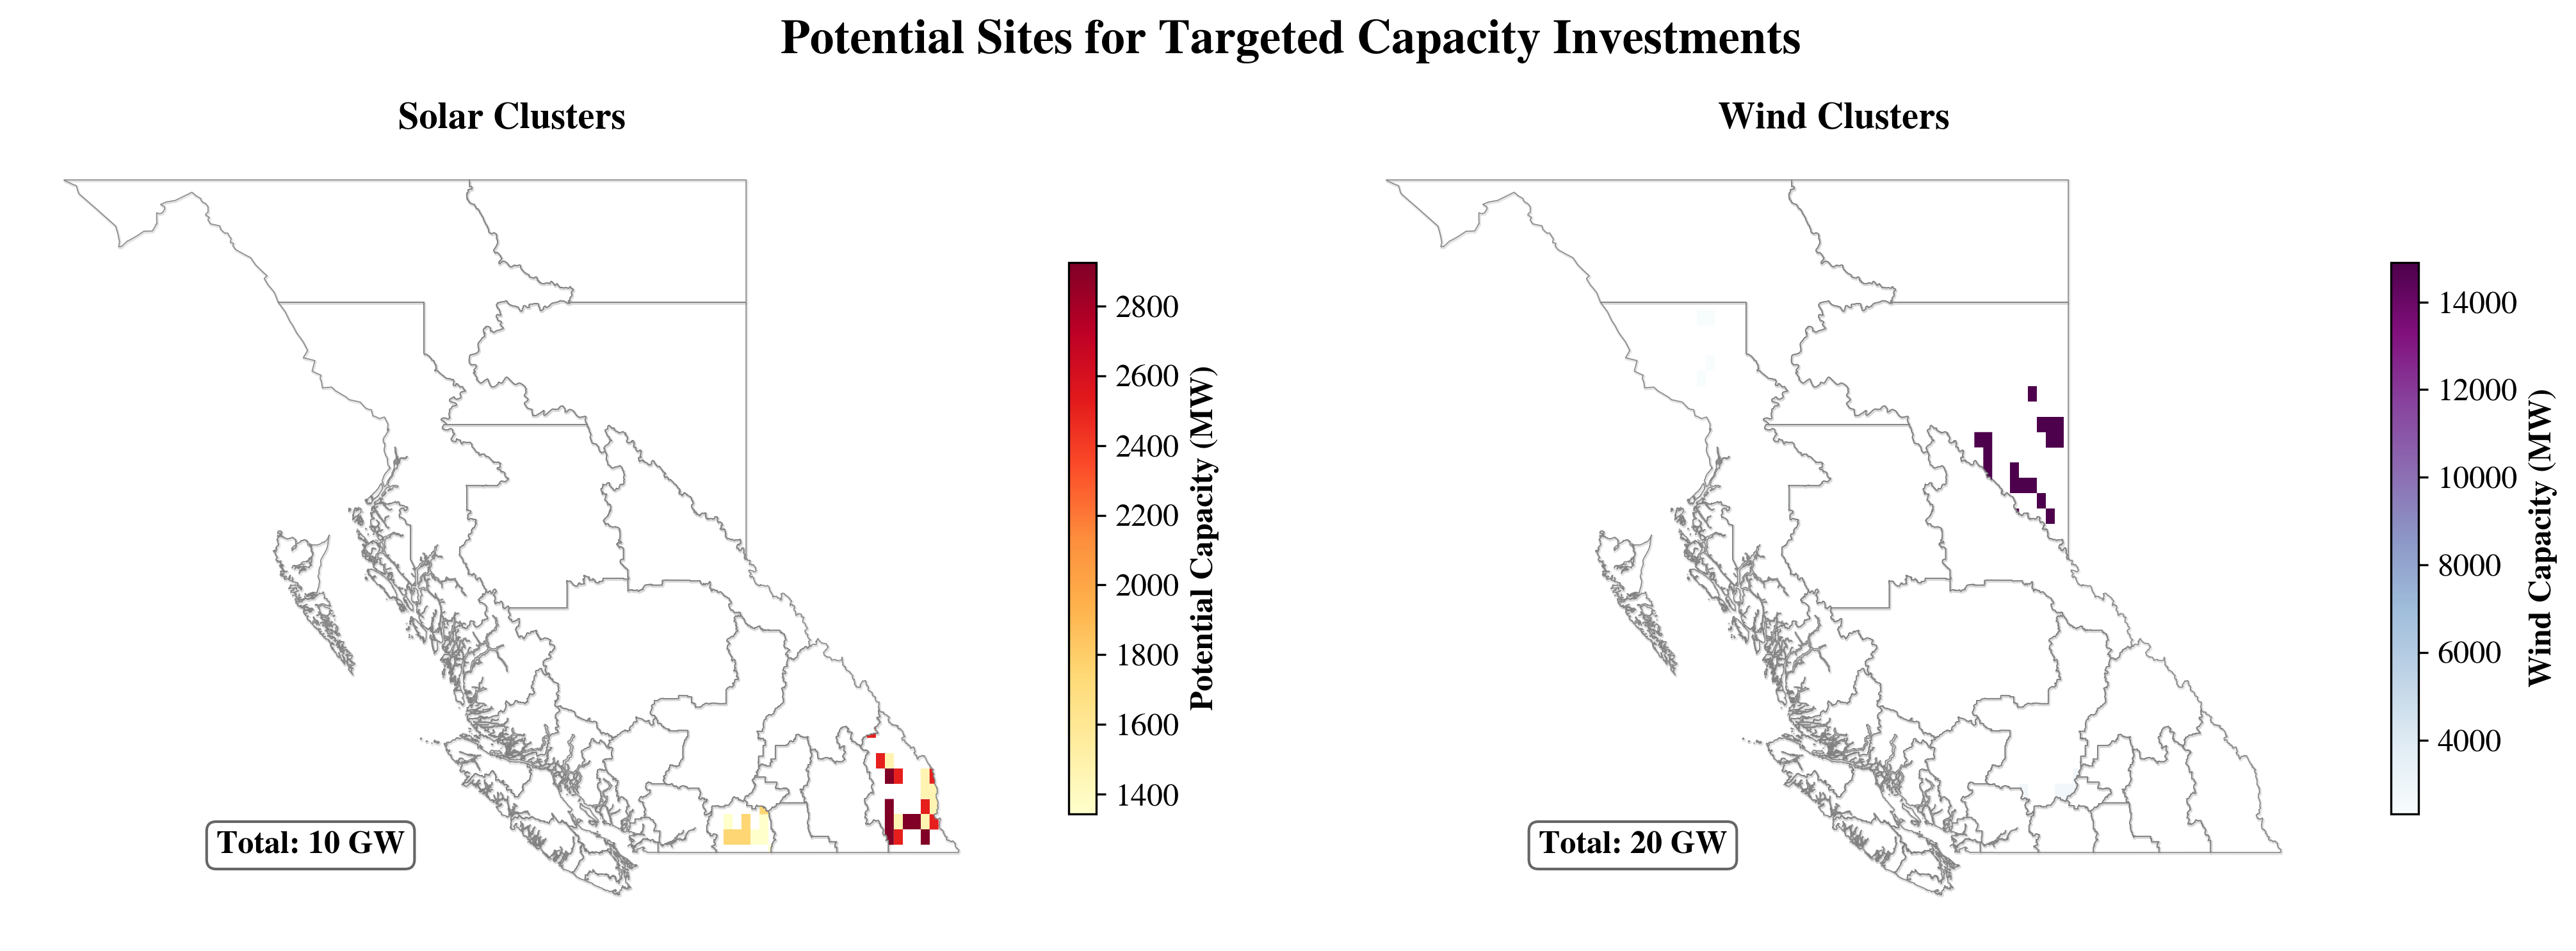

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

legend_x_ax_offset = 1

# Ensure 'Region' in boundary
if 'Region' not in boundary.columns:
    boundary = boundary.reset_index(inplace=True)

# Assign region numbers
boundary['Region_Number'] = range(1, len(boundary) + 1)

# Compute totals
solar_total_GW = resource_clusters_solar['potential_capacity'].sum()/1E3
wind_total_GW = resource_clusters_wind['potential_capacity'].sum()/1E3

# Create figure and axes
fig, (ax1, ax2) = plt.subplots(figsize=(14, 5), ncols=2, dpi=300)
fig.suptitle("Potential Sites for Targeted Capacity Investments", 
             fontsize=18, weight='bold')

ax1.set_axis_off()
ax2.set_axis_off()

shadow_offset = 0.02

# --- Solar Map ---
boundary.geometry = boundary.geometry.translate(xoff=shadow_offset, yoff=-shadow_offset)
boundary.plot(ax=ax1, color='none', edgecolor='lightgrey', linewidth=1, alpha=0.6)
boundary.geometry = boundary.geometry.translate(xoff=-shadow_offset, yoff=shadow_offset)

im1 = resource_clusters_solar.plot(
    column='potential_capacity',
    ax=ax1,
    cmap='YlOrRd',
    legend=True,
    legend_kwds={'label': "Solar Capacity (MW)", 'shrink': 0.7, 'orientation': 'vertical'}
)

# Get the colorbar and set font size
cbar1 = ax1.get_figure().get_axes()[-1]  # Get the colorbar axes
cbar1.tick_params(labelsize=12)
cbar1.set_ylabel("Potential Capacity (MW)", fontsize=12, weight='bold')

boundary.plot(ax=ax1, facecolor='none', edgecolor='grey', linewidth=0.4, alpha=0.9)
ax1.set_title("Solar Clusters", fontsize=14, weight="bold")

# Annotation for total solar capacity
ax1.annotate(
    f"Total: {solar_total_GW:,.0f} GW",
    xy=(0.2, 0.1), xycoords="axes fraction",
    fontsize=12, weight="bold", color="black",
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.6, boxstyle="round,pad=0.3")
)

# --- Wind Map ---
boundary.geometry = boundary.geometry.translate(xoff=shadow_offset, yoff=-shadow_offset)
boundary.plot(ax=ax2, color='none', edgecolor='lightgrey', linewidth=1, alpha=0.6)
boundary.geometry = boundary.geometry.translate(xoff=-shadow_offset, yoff=shadow_offset)

im2 = resource_clusters_wind.plot(
    column='potential_capacity',
    ax=ax2,
    cmap='BuPu',
    legend=True,
    legend_kwds={'label': "Potential Capacity (MW)", 'shrink': 0.7, 'orientation': 'vertical'}
)

# Get the colorbar and set font size
cbar2 = ax2.get_figure().get_axes()[-1]  # Get the colorbar axes
cbar2.tick_params(labelsize=12)
cbar2.set_ylabel("Wind Capacity (MW)", fontsize=12, weight='bold')

boundary.plot(ax=ax2, facecolor='none', edgecolor='grey', linewidth=0.4, alpha=0.9)
ax2.set_title("Wind Clusters", fontsize=14, weight="bold")

# Annotation for total wind capacity
ax2.annotate(
    f"Total: {wind_total_GW:,.0f} GW",
    xy=(0.2, 0.1), xycoords="axes fraction",
    fontsize=12, weight="bold", color="black",
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.6, boxstyle="round,pad=0.3")
)

# Layout
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.subplots_adjust(top=0.85)

# plt.show()
# plt.savefig(f"../vis/{region_code}/invested_resources_{region_code}_{RUN_ID}.png", dpi=300, bbox_inches='tight')